#**Statistical Assessement of Potentially Habitable Exoplanets**

**README**

 - Please run inside Colab environment only

 - Redundant code lines are intentionally retained for independent future usage and contributions from each member is kept as standalone streamline for same reason.

 - Youtube link of the Presentation: https://youtu.be/lL-Vw2irtO0?si=Ewht60r_QNdhcfQu


#**1. Calling Packages**

In [1]:
#Importing all necessary packages

!pip install uncertainties
!pip install emcee

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy.random as rd
import emcee
import seaborn as sns
from uncertainties import ufloat
from IPython.display import display

#mpl.rcParams.update(mpl.rcParamsDefault)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 858.7 kB/s eta 0:00:00


#**2. Loading Data File**

In [2]:
#Data file upload

from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving NASA_Exoplanet_Catalogue.csv to NASA_Exoplanet_Catalogue.csv
User uploaded file "NASA_Exoplanet_Catalogue.csv" with length 14919436 bytes


**Notes:**

We used NASA Exoplanet Catalogue.

**Link:** https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=PS

#**3. Filtering dataset to remove duplicate entries and extract entries where all the parameters for flux calculation is present.**

We used temperature and radius of host star, semi-major axis of planet and eccentricity of orbit to find expected flux.

In [4]:
#Data Filteration

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name, comment='#')                                       #Read file (skip NASA comment lines)


# Convert update column to datetime
df['rowupdate'] = pd.to_datetime(df['rowupdate'], errors='coerce')


# Sort so latest entries are retained

df = df.sort_values(by='rowupdate')

df = df.drop_duplicates(subset='pl_name', keep='last')

N = len(df)

print(f"Total Planets after removing duplicates: {N}")

cols = ['pl_rade', 'pl_radeerr1', #'pl_radeerr2',
        'pl_orbeccen', 'pl_orbeccenerr1', #'pl_orbeccenerr2',
        'pl_orbsmax', 'pl_orbsmaxerr1', #'pl_orbsmaxerr2',
        'st_teff', 'st_tefferr1', #'st_tefferr2',
        'st_rad', 'st_raderr1', #'st_raderr2'
        ]    #Relevant data columns


df = df.replace(r'^\s*$', pd.NA, regex=True)               #Clean blanks - NaN


for col in cols:                                           #Force numeric conversion
    df[col] = pd.to_numeric(df[col], errors='coerce')


filtered_df = df.dropna(subset=cols)                       #Extraction of rows with required fields

filtered_df = filtered_df[['pl_name'] + cols]

n_flux = len(filtered_df)

print(f"Planets whose flux can be calculated: {n_flux}")

print(filtered_df)

Total Planets after removing duplicates: 6158
Planets whose flux can be calculated: 173
             pl_name    pl_rade  pl_radeerr1  pl_orbeccen  pl_orbeccenerr1  \
25196    Kepler-35 b   8.160000     0.157000       0.0420           0.0070   
35979          PH1 b   6.180000     0.170000       0.0702           0.0029   
24913    Kepler-34 b   8.564000     0.135000       0.1820           0.0160   
351       CoRoT-22 b   4.880000     0.170000       0.0770           0.3000   
15844  Kepler-1647 b  11.873900     0.137700       0.0581           0.0689   
...              ...        ...          ...          ...              ...   
37047     TOI-3288 b  12.240207     0.369896       0.0210           0.0260   
37322     TOI-5007 b  11.074473     0.347478       0.0740           0.0260   
37277     TOI-4666 b  12.531640     0.392314       0.0230           0.0330   
37366   TOI-5292 A b  12.643730     0.437150       0.0340           0.0240   
36242     TOI-1232 b  10.928756     0.594076       0.0

#**4. Calculation of Flux: (Theoretical Values Using Idealized Conditions)**

We used a blackbody model to calculate flux recieved by the planet. Star is considered to be stable and is assumed to radiate energy per unit time according to Stefan's law:

$$P = 4 \pi R_{star}^2 \sigma T_{star}^4$$

where, $R$ and $T$ are stellar mass and temperature respectively.

$$F_{planet} = \frac{\sigma R_{star}^2 T_{star}^4}{a^2}\frac{1}{\sqrt{1 - e^2}}$$

here, $A$ is Albedo and is dependent on atmospheric composition,\
$\sigma$ is Stefan's constant,\
$a$ is semi-major axis of planet's orbit and,\
$e$ is eccentricity of planet's orbit

While calculation, flux is scaled wrt Earth's values. So, radius is given in units of solar radius, $a$ is given in units of AU (Semi-major axis of Earth ($\approx149.6 \times 10^{6}$ km)).

Relative flux is thus:

$$F_{planet} = \frac{1}{a^2} \left( \frac{R_{star}}{R_{sun}}\right)^2 \left( \frac{T_{star}}{T_{sun}}\right)^4 \sqrt{\frac{1 - e_{Earth}^2}{1 - e_{planet}^2}}$$

here, $a_{Earth} = 1$

While, stars and planets are not perfect blackbodies, exhibiting deviation and atmospheric data is required for measurement of Albedo value is required to predict flux, we can model flux by assuming perfectly absorbing planet ($A = 0$) or by assuming Earth-like atmosphere $(A = 0.3)$.

In [5]:
#Calculation of Flux using theoretical model


T_sun = 5778  # Kelvin
e_earth = 0.0167


#CSV columns to lists

names = filtered_df['pl_name'].tolist()
R_star = filtered_df['st_rad'].tolist()
T_star = filtered_df['st_teff'].tolist()
a = filtered_df['pl_orbsmax'].tolist()
e = filtered_df['pl_orbeccen'].tolist()


def safe_val(x):
    return 0 if np.isnan(x) else x


#Flux Calculation

flux_list = []
flux_err_list = []

for i in range(n_flux):

    try:
        R = filtered_df['st_rad'].iloc[i]
        T = filtered_df['st_teff'].iloc[i]
        a_val = filtered_df['pl_orbsmax'].iloc[i]
        e_val = filtered_df['pl_orbeccen'].iloc[i]

        R_err = safe_val(filtered_df['st_raderr1'].iloc[i])
        T_err = safe_val(filtered_df['st_tefferr1'].iloc[i])
        a_err = safe_val(filtered_df['pl_orbsmaxerr1'].iloc[i])
        e_err = safe_val(filtered_df['pl_orbeccenerr1'].iloc[i])

        # Exception Handling

        if (1 - e_val**2) <= 0 or a_val < 0:
            flux_list.append(np.nan)
            flux_err_list.append(np.nan)
            continue


        R_u = ufloat(R, R_err)
        T_u = ufloat(T, T_err)
        a_u = ufloat(a_val, a_err)
        e_u = ufloat(e_val, e_err)

        F = ((R_u**2) * (T_u / T_sun)**4 / a_u**2) * ((1 - e_earth**2) / (1 - e_u**2))**0.5

        flux_list.append(F.nominal_value)
        flux_err_list.append(F.std_dev)

    except Exception as err:
        print(f"Error at index {i}: {err}")
        flux_list.append(np.nan)
        flux_err_list.append(np.nan)


n = len(flux_list)

#Results

for i in range(0,n,1):
    print(f"Planet: {names[i]} \t Flux: {flux_list[i]}")

print(f"Highest Flux: {max(flux_list)}")
print(f"Lowest Flux: {min(flux_list)}")



Planet: Kepler-35 b 	 Flux: 2.575359173942841
Planet: PH1 b 	 Flux: 10.718251116819458
Planet: Kepler-34 b 	 Flux: 1.267955355443197
Planet: CoRoT-22 b 	 Flux: 170.66909608221698
Planet: Kepler-1647 b 	 Flux: 0.5787407852816807
Planet: K2-125 b 	 Flux: 1.772182019913287
Planet: K2-72 b 	 Flux: 7.880976240514672
Planet: K2-72 c 	 Flux: 2.072577578044621
Planet: Kepler-1654 b 	 Flux: 0.3087437001501654
Planet: Kepler-453 b 	 Flux: 0.930621797585698
Planet: K2-292 b 	 Flux: 67.8024286672188
Planet: CoRoT-16 b 	 Flux: 364.8459140528412
Planet: EPIC 212737443 c 	 Flux: 2.546098940483138
Planet: EPIC 212737443 b 	 Flux: 20.784481146801124
Planet: EPIC 249893012 d 	 Flux: 47.65594389378015
Planet: EPIC 249893012 c 	 Flux: 135.26977035506627
Planet: EPIC 249893012 b 	 Flux: 1034.208838897266
Planet: Kepler-1661 b 	 Flux: 0.8808849058884736
Planet: CoRoT-30 b 	 Flux: 106.27512011016891
Planet: CoRoT-31 b 	 Flux: 1274.9620798109158
Planet: K2-35 c 	 Flux: 43.0845584343213
Planet: K2-35 b 	 Flux:

#**5. Frequency Distribution and Error Propagation**

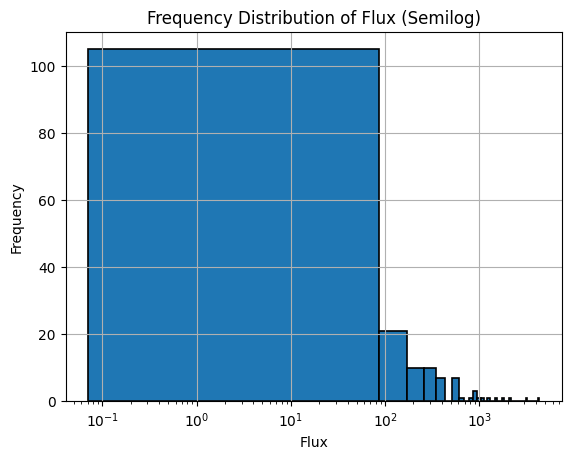

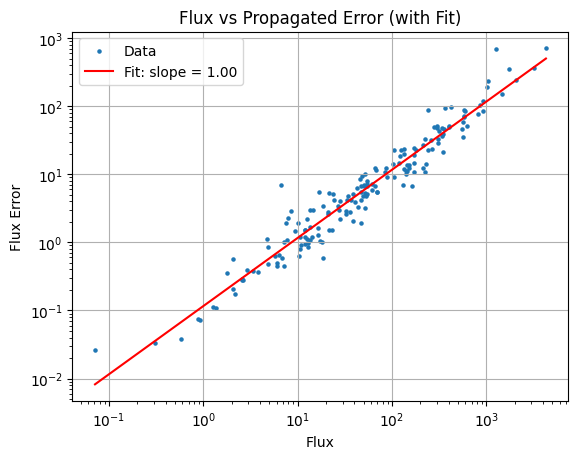

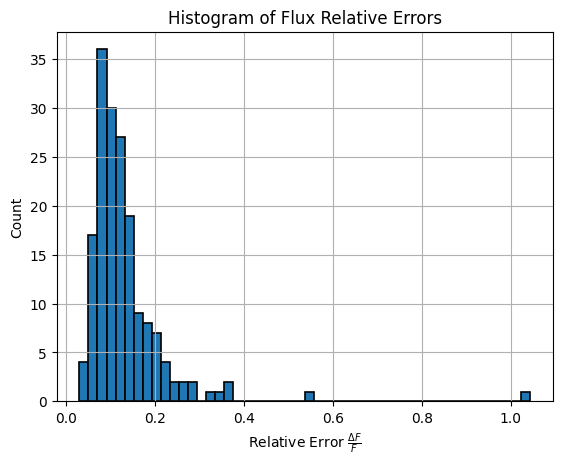

In [6]:
flux_list = np.array(flux_list)
flux_err_list = np.array(flux_err_list)


#Removing invalid values (For log + fitting)

mask = ((flux_list > 0) & (flux_err_list > 0) & np.isfinite(flux_list) & np.isfinite(flux_err_list))

flux_list = flux_list[mask]
flux_err_list = flux_err_list[mask]


#Log conversion

log_flux = np.log10(flux_list)
log_err = np.log10(flux_err_list)


# Linear fit in log-log space

coeffs = np.polyfit(log_flux, log_err, 1)
slope, intercept = coeffs


# Sort for clean line plotting

sorted_idx = np.argsort(log_flux)
log_flux = log_flux[sorted_idx]
fit_line = slope * log_flux + intercept


#Graphs

plt.hist(flux_list, bins=50, edgecolor='black', linewidth=1.2)

plt.xscale('log')
plt.xlabel("Flux")
plt.ylabel("Frequency")
plt.title("Frequency Distribution of Flux (Semilog)")
plt.grid()
plt.show()


#Error Propagation

plt.scatter(flux_list, flux_err_list, s=5, label="Data")

#Fit line (Revert from log space)

fit_flux = 10**log_flux
fit_err = 10**fit_line

plt.plot(fit_flux, fit_err, color='red', label=f"Fit: slope = {slope:.2f}")

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Flux")
plt.ylabel("Flux Error")
plt.title("Flux vs Propagated Error (with Fit)")
plt.legend(loc='best')
plt.grid()
plt.show()


flux_rel_err = flux_err_list / flux_list


plt.hist(flux_rel_err, bins=50, edgecolor='black', linewidth=1.2)

plt.xlabel(r"Relative Error $\frac{\Delta F}{F}$")
plt.ylabel("Count")
plt.title("Histogram of Flux Relative Errors")
plt.grid()
plt.show()

#**6(a) Classification of Exoplanets using Bayesian MCMC**
#**(Mass + Radius)**

##**Use of MCMC in Mass-Radius Based Classification**

The planetary structure is modeled using a power-law relation:

$$R = k M^{\alpha}$$

where, $k$ and $\alpha$ characterize different planet classes.

- $\alpha$ controls how radius varies with mass

- $k$ is scaling constant

A Bayesian approach is adopted to incorporate observational uncertainties in mass ($M$) and radius ($R$). Using Bayes' theorem:

$$P(\theta \mid M, R) \propto P(R \mid M, \theta)\,P(\theta)$$

where $\theta = (\alpha, k)$, $P(R \mid M, \theta)$ is the likelihood, and $P(\theta)$ is the prior.


Markov Chain Monte Carlo (MCMC) is used to:

- sample the posterior distribution of $(\alpha, k)$,
- account for measurement uncertainties,
- explore degeneracies in the mass--radius relation.


Classification is performed by evaluating likelihoods over the sampled parameter space, yielding probabilistic class assignments instead of deterministic labels.

In [7]:
file_name = list(uploaded.keys())[0]
df2 = pd.read_csv(file_name, comment='#')

df2 = df2.replace(r'^\s*$', pd.NA, regex=True)


#Removing Duplicates

df2['rowupdate'] = pd.to_datetime(df2['rowupdate'], errors='coerce')
df2 = df2.dropna(subset=['rowupdate'])
df2 = df2.sort_values('rowupdate')
df2 = df2.drop_duplicates('pl_name', keep='last')


#Parameters

cols = ['pl_masse','pl_masseerr1','pl_rade','pl_radeerr1']
for c in cols:
    df2[c] = pd.to_numeric(df2[c], errors='coerce')

df2 = df2.dropna(subset=['pl_masse','pl_rade'])
df2 = df2[(df2['pl_masse'] > 0) & (df2['pl_rade'] > 0)]

M = df2['pl_masse'].to_numpy(dtype=float)
R = df2['pl_rade'].to_numpy(dtype=float)


#Uncertainties

R_err = df2['pl_radeerr1'].abs()
R_err = R_err.to_numpy(dtype=float)
R_err = np.where(np.isnan(R_err), 0.2 * R, R_err)

M_err = df2['pl_masseerr1'].abs().to_numpy(dtype=float)
M_err = np.where(np.isnan(M_err), 0.2 * M, M_err)

R_err = np.clip(R_err, 1e-8, None)
M_err = np.clip(M_err, 1e-8, None)


#Error Propagation

def sigma_eff(M, M_err, R_err, alpha, k):
    dR_dM = k * alpha * M**(alpha - 1)
    model_err = np.abs(dR_dM) * M_err
    sigma = np.sqrt(R_err**2 + model_err**2)

    return np.clip(sigma, 1e-8, None)


# 6. Log Likelihood (Normalized)

def log_likelihood(theta, M, R, M_err, R_err):
    alpha, k = theta

    if k <= 0:
        return -np.inf

    R_pred = k * M**alpha
    sigma = sigma_eff(M, M_err, R_err, alpha, k)

    return -0.5 * np.sum(((R - R_pred)/sigma)**2 + np.log(2*np.pi*sigma**2))


#Priors (Gaussian + Normalized)

def log_prior(theta, kind):
    alpha, k = theta

    if kind == "rock":
        mu_a, sig_a = 0.3, 0.05
        mu_k, sig_k = 1.0, 0.5
    elif kind == "ice":
        mu_a, sig_a = 0.2, 0.05
        mu_k, sig_k = 5.0, 1.5
    elif kind == "gas":
        mu_a, sig_a = 0.0, 0.05
        mu_k, sig_k = 10.0, 3.0
    else:
        return -np.inf

    if k <= 0:
        return -np.inf

    logp_a = -0.5 * ((alpha - mu_a)/sig_a)**2 \
             - np.log(sig_a * np.sqrt(2*np.pi))   #Normalized

    logp_k = -0.5 * ((k - mu_k)/sig_k)**2 \
             - np.log(sig_k * np.sqrt(2*np.pi))   #Normalized

    return logp_a + logp_k


#Posterior

def log_post(theta, kind, M, R, M_err, R_err):
    lp = log_prior(theta, kind)
    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood(theta, M, R, M_err, R_err)


#MCMC

ndim, nwalkers, steps = 2, 40, 3000

def run_sampler(kind, init):
    pos = init + 1e-2 * np.random.randn(nwalkers, ndim)

    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_post, args=(kind, M, R, M_err, R_err))

    sampler.run_mcmc(pos, steps, progress=True)

    return sampler.get_chain(discard=500, flat=True)



samples = {
    "rock": run_sampler("rock", np.array([0.3, 1.0])),
    "ice":  run_sampler("ice",  np.array([0.2, 5.0])),
    "gas":  run_sampler("gas",  np.array([0.0, 10.0]))
}


#Numerical Stability

def logsumexp(a):
    a_max = np.max(a)
    return a_max + np.log(np.sum(np.exp(a - a_max)))


#Classification

def classify_planet(Mi, Ri, Mi_err, Ri_err):

    logL_vals = []

    for key in ["rock","ice","gas"]:
        alpha = samples[key][:,0]
        k = samples[key][:,1]

        sigma = np.sqrt(Ri_err**2 + (k * alpha * Mi**(alpha-1) * Mi_err)**2)
        sigma = np.clip(sigma, 1e-8, None)

        R_pred = k * Mi**alpha

        logL = -0.5 * (((Ri - R_pred)/sigma)**2 + np.log(2*np.pi*sigma**2))

        logL_mean = logsumexp(logL) - np.log(len(logL))
        logL_vals.append(logL_mean)

    logL_vals = np.array(logL_vals)
    log_norm = logsumexp(logL_vals)

    probs = np.exp(logL_vals - log_norm)

    return probs



#Simulation

P_rock, P_ice, P_gas, labels = [], [], [], []

for i in range(0,len(M),1):
    pr, pi, pg = classify_planet(M[i], R[i], M_err[i], R_err[i])

    P_rock.append(pr)
    P_ice.append(pi)
    P_gas.append(pg)

    labels.append(["Rocky","Ice Giant","Gas Giant"][np.argmax([pr,pi,pg])])


df2['P_rock'] = P_rock
df2['P_ice'] = P_ice
df2['P_gas'] = P_gas
df2['Class'] = labels

df2 = df2[['pl_name','pl_masse','pl_rade','P_rock','P_ice','P_gas','Class']]
df2 = df2.sort_values('pl_name').reset_index(drop=True)


#Result

print(df2.head())
print(f"\nTotal: {len(df2)}")

df2.to_csv("Classified_exoplanets_1.csv", index=False)
files.download("Classified_exoplanets_1.csv")


#files.download("/home/abhishank/Assignments/MSc-Assignments/MSP-5132-Assignments/Classified_exoplanets_1.csv")

100%|██████████| 3000/3000 [00:12<00:00, 239.32it/s]


                     pl_name     pl_masse    pl_rade    P_rock     P_ice  \
0  2MASS J02192210-3925225 b  4417.837000  16.140960  0.409935  0.406204   
1  2MASS J12073346-3932539 b  1652.707716  15.692573  0.408742  0.407307   
2                   AU Mic b     8.990000   4.790000  0.407207  0.407232   
3                   AU Mic c    14.460000   2.790000  0.408463  0.408485   
4                BD+20 594 b    22.248100   2.578070  0.408340  0.408366   

      P_gas      Class  
0  0.183861      Rocky  
1  0.183951      Rocky  
2  0.185561  Ice Giant  
3  0.183052  Ice Giant  
4  0.183294  Ice Giant  

Total: 539


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Note: Gaussian distribution is prone to less misclassification compared to uniform while using as Prior in Bayesian. However, we cross-checked with some random planets from internet and found that there is a blur in the boundary of rocky and ice-giant and ice giant and gas giants, which is noticeable for the latter in our classification model.

#**6(b) Plots (Mass + Radius)**

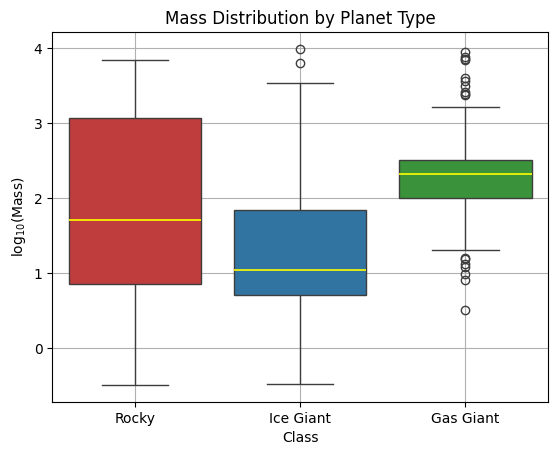

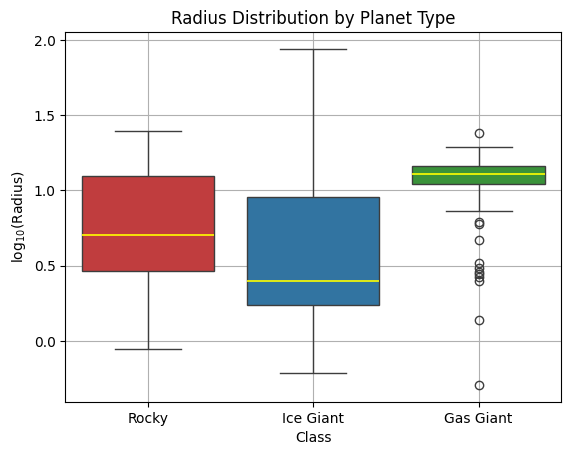

In [ ]:
df3 = pd.read_csv("Classified_exoplanets_1.csv", comment='#')


#Boxplots

df3['logM'] = np.log10(df3['pl_masse'])
df3['logR'] = np.log10(df3['pl_rade'])


#Class Separation

rock = df3[df3['Class'] == "Rocky"]
ice = df3[df3['Class'] == "Ice Giant"]
gas = df3[df3['Class'] == "Gas Giant"]


#Plot Attributes

order = ["Rocky", "Ice Giant", "Gas Giant"]

colours = {"Rocky": "#d62728", "Ice Giant": "#1f77b4", "Gas Giant": "#2ca02c"}

# Mass

sns.boxplot(x='Class', y='logM', data=df3, order=order, hue='Class', palette=colours, medianprops=dict(color='yellow', linewidth=1.2), legend=False)

plt.ylabel("log$_{10}$(Mass)")
plt.title("Mass Distribution by Planet Type")
plt.grid()
plt.show()


# Radius

sns.boxplot(x='Class', y='logR', data=df3, order=order, hue='Class', palette=colours, medianprops=dict(color='yellow', linewidth=1.2), legend=False)

plt.ylabel("log$_{10}$(Radius)")
plt.title("Radius Distribution by Planet Type")
plt.grid()
plt.show()

Note: Rocky vs non-rocky classification is not good as the model only accounts for mass and radius. We need to include density parameter to fix degeneracy in:

1. Solid rocky core sorrounded by water and hydrogen atmosphere.
2. Silicate crust with iron core.
3. Rocky core and gas envelope.
4. Only rocky body.

All these can arise for planets having same mass.


#**7(a) Classification of Exoplanets Using Bayesian MCMC**

#**(Mass + Radius + Density)**

In [ ]:
#Data Loading

file_name = "Classified_exoplanets_1.csv"       #Refining the classification using previous results
df2 = pd.read_csv(file_name, comment='#')


M = df2['pl_masse'].to_numpy(dtype=float)
R = df2['pl_rade'].to_numpy(dtype=float)



#Uncertainties

R_err = df2.get('pl_radeerr1', pd.Series(np.nan)).abs().to_numpy()
R_err = np.where(np.isnan(R_err), 0.2 * R, R_err)

M_err = df2.get('pl_masseerr1', pd.Series(np.nan)).abs().to_numpy()
M_err = np.where(np.isnan(M_err), 0.2 * M, M_err)

R_err = np.clip(R_err, 1e-8, None)
M_err = np.clip(M_err, 1e-8, None)



#Error Propagation

def sigma_eff(M, M_err, R_err, alpha, k):
    dR_dM = k * alpha * M**(alpha - 1)
    model_err = np.abs(dR_dM) * M_err

    return np.sqrt(R_err**2 + model_err**2)



#Density

def log_density_likelihood(log_rho, kind):
    if kind == "rock":
        mu, sigma = 0.3, 0.3
    elif kind == "ice":
        mu, sigma = -0.3, 0.3
    else:
        mu, sigma = -1.0, 0.5

    return -0.5 * ((log_rho - mu)/sigma)**2 - np.log(sigma*np.sqrt(2*np.pi))



#Mass

def log_mass_prior(M, kind):
    logM = np.log10(M)

    if kind == "rock":
        mu, sigma = 0.5, 0.5
    elif kind == "ice":
        mu, sigma = 1.5, 0.5
    else:
        mu, sigma = 2.5, 0.7

    return -0.5 * ((logM - mu)/sigma)**2 - np.log(sigma*np.sqrt(2*np.pi))



# 8. LOG LIKELIHOOD

def log_likelihood(theta, kind, M, R, M_err, R_err):
    alpha, k = theta

    if k <= 0:
        return -np.inf

    # Radius likelihood
    R_pred = k * M**alpha
    sigma = sigma_eff(M, M_err, R_err, alpha, k)

    logL_R = -0.5 * np.sum(((R - R_pred)/sigma)**2 + np.log(2*np.pi*sigma**2))

    # Density likelihood
    rho = M / R**3
    log_rho = np.log10(rho)
    logL_rho = np.sum(log_density_likelihood(log_rho, kind))

    # Mass prior contribution
    logL_M = np.sum(log_mass_prior(M, kind))

    return logL_R + logL_rho + logL_M



#Parameter (Gaussian)

def log_prior(theta):
    alpha, k = theta

    #Gaussian priors

    mu_alpha, sig_alph = 0.2, 0.2
    mu_k, sig_k = 5.0, 5.0

    return (
        -0.5 * ((alpha - mu_alpha) / sig_alph)**2 - np.log(sig_alph * np.sqrt(2 * np.pi))
        -0.5 * ((k - mu_k) / sig_k)**2 - np.log(sig_k * np.sqrt(2 * np.pi)))



#Posterior

def log_post(theta, kind, M, R, M_err, R_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood(theta, kind, M, R, M_err, R_err)


#MCMC

ndim, nwalkers, steps = 2, 40, 3000

def run_sampler(kind, init):
    pos = init + 1e-2 * np.random.randn(nwalkers, ndim)
    sampler = emcee.EnsembleSampler(
        nwalkers, ndim, log_post,
        args=(kind, M, R, M_err, R_err)
    )
    sampler.run_mcmc(pos, steps, progress=True)

    return sampler.get_chain(discard=500, flat=True)

samples = {
    "rock": run_sampler("rock", np.array([0.3, 1.0])),
    "ice":  run_sampler("ice",  np.array([0.2, 5.0])),
    "gas":  run_sampler("gas",  np.array([0.0, 10.0]))
}



#Classification

def logsumexp(a):
    a_max = np.max(a)
    return a_max + np.log(np.sum(np.exp(a - a_max)))


def classify_planet(Mi, Ri, Mi_err, Ri_err):
    logL_vals = []

    for key in ["rock","ice","gas"]:
        alpha = samples[key][:,0]
        k = samples[key][:,1]

        sigma = np.sqrt(Ri_err**2 + (k * alpha * Mi**(alpha-1) * Mi_err)**2)
        sigma = np.clip(sigma, 1e-8, None)

        R_pred = k * Mi**alpha
        logL_R = -0.5 * ((Ri - R_pred)/sigma)**2

        rho_i = Mi / Ri**3
        logL_rho = log_density_likelihood(np.log10(rho_i), key)

        logL_M = log_mass_prior(Mi, key)

        logL = logL_R + logL_rho + logL_M

        logL_mean = logsumexp(logL) - np.log(len(logL))
        logL_vals.append(logL_mean)

    logL_vals = np.array(logL_vals)
    log_norm = logsumexp(logL_vals)
    probs = np.exp(logL_vals - log_norm)

    return probs



#Simulation

labels = []

for i in range(0,len(M),1):
    pr, pi, pg = classify_planet(M[i], R[i], M_err[i], R_err[i])
    labels.append(["Rocky","Ice Giant","Gas Giant"][np.argmax([pr,pi,pg])])


df2['Class'] = labels


df2.to_csv("Classified_exoplanets_mass_density.csv", index=False)
files.download("Classified_exoplanets_mass_density.csv")


print(df2.head())
print(f"\nTotal Planets Classified: {len(df2)}")

100%|██████████| 3000/3000 [00:19<00:00, 150.83it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

                     pl_name     pl_masse    pl_rade    P_rock     P_ice  \
0  2MASS J02192210-3925225 b  4417.837000  16.140960  0.371092  0.377983   
1  2MASS J12073346-3932539 b  1652.707716  15.692573  0.378326  0.379984   
2                   AU Mic b     8.990000   4.790000  0.380202  0.381351   
3                   AU Mic c    14.460000   2.790000  0.381246  0.380805   
4                BD+20 594 b    22.248100   2.578070  0.381158  0.380840   

      P_gas      Class  
0  0.250925  Gas Giant  
1  0.241690  Gas Giant  
2  0.238447  Gas Giant  
3  0.237949  Ice Giant  
4  0.238002  Ice Giant  

Total Planets Classified: 539


#**7(b) Plots (Mass + Radius + Density)**

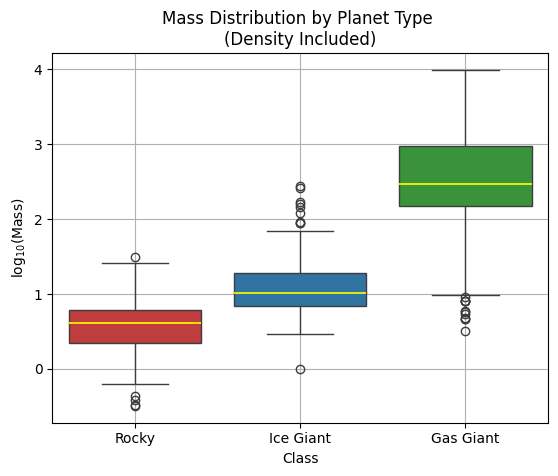

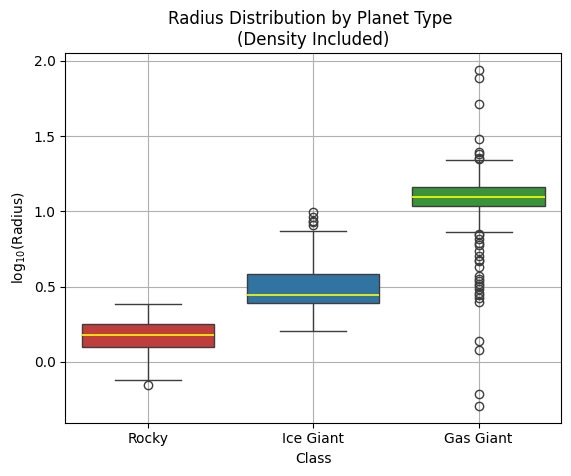

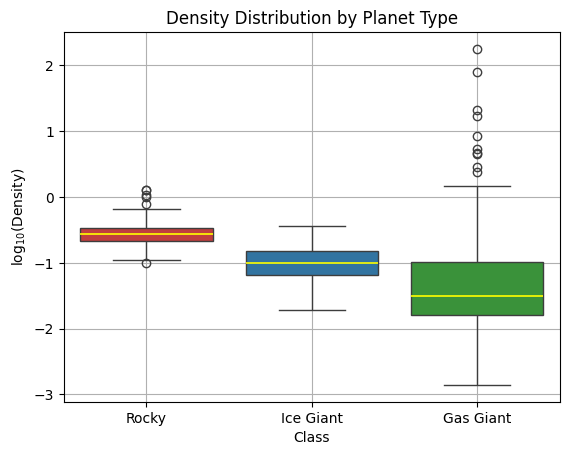

In [ ]:
#Boxplots

df2['logM'] = np.log10(df2['pl_masse'])
df2['logR'] = np.log10(df2['pl_rade'])
df2['rho'] = df2['pl_masse'] / ((4/3 * np.pi) * df2['pl_rade']**3)
df2['logrho'] = np.log10(df2['rho'])


#Class Separation

rock = df2[df2['Class'] == "Rocky"]
ice = df2[df2['Class'] == "Ice Giant"]
gas = df2[df2['Class'] == "Gas Giant"]


#Plot Attributes

order = ["Rocky", "Ice Giant", "Gas Giant"]

colours = {"Rocky": "#d62728", "Ice Giant": "#1f77b4", "Gas Giant": "#2ca02c"}

# Mass

sns.boxplot(x='Class', y='logM', data=df2, order=order, hue='Class', palette=colours, medianprops=dict(color='yellow', linewidth=1.2), legend=False)

plt.ylabel("log$_{10}$(Mass)")
plt.title("Mass Distribution by Planet Type \n(Density Included)")
plt.grid()
plt.show()


# Radius

sns.boxplot(x='Class', y='logR', data=df2, order=order, hue='Class', palette=colours, medianprops=dict(color='yellow', linewidth=1.2), legend=False)

plt.ylabel("log$_{10}$(Radius)")
plt.title("Radius Distribution by Planet Type \n(Density Included)")
plt.grid()
plt.show()


#Density

sns.boxplot(x='Class', y='logrho', data=df2, order=order, hue='Class', palette=colours, medianprops=dict(color='yellow', linewidth=1.2), legend=False)

plt.ylabel("log$_{10}$(Density)")
plt.title("Density Distribution by Planet Type")
plt.grid()
plt.show()

**Notes:**

1. Rocky vs non-rocky bodies are well separated in the plots, indicating that density plays the dominant role in classification.

2. Inclusion of density $\rho$ managed to separate out the major classifications. However, a large number of outliers at the lower end of Gas Giants' boxplots in mass and radius plots indicate ambiguity in being warm-Neptunes or Hot-Jupiters.

3. Similar uncertainty lies between being Mini-Neptunes or Super-Earth due to unknown exact composition and apparently similar density.

4. Outlier behaviour and degeneracies may be further curbed by inclusion of escape temperature of atmospheric gasses and modelling Greenhouse effects.

    Escape temperature is the temperature at which gas molecules attain thermal kinetic energy that is enough to escape a planet's gravitaional bound.

    Mathematically for the atmosphere to survive for 4.5 billion years, we require:
    
    \begin{align}
    v_{rms} & < \frac{1}{6} v_{esc} \\
    \implies T_{esc} & = \frac{GMm}{54k_BR}
    \end{align}
    


    Assuming Maxwell-Boltzmann distribution and atmosphere to survive for 4.5 billion years.

    Here, $v_{rms} = \sqrt{\frac{3k_BT}{m}}$ and $v_{esc} = \sqrt{\frac{2GM}{R}}$

5. More conservative estimates will use a factor of 1/10 instead of 1/6, for greater longevity.

#**7(c). Correlation Heatmaps**

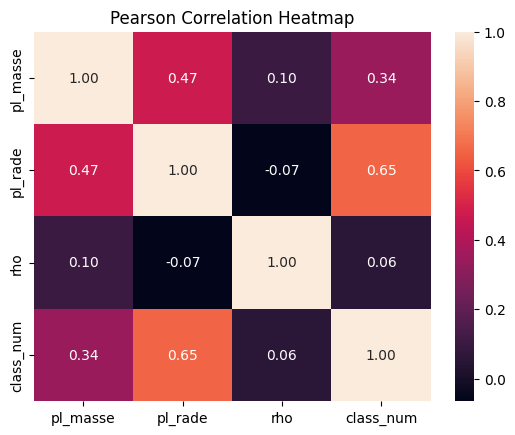

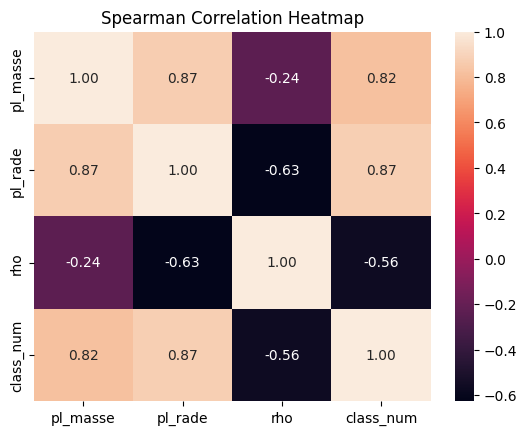

In [ ]:
#Class

class_map = {"Rocky":0, "Ice Giant":1, "Gas Giant":2}
df2['class_num'] = df2['Class'].map(class_map)


#Features

features = ['pl_masse', 'pl_rade', 'rho', 'class_num']
data = df2[features].dropna()


#Pearson Correlation

pearson_corr = data.corr(method='pearson')

sns.heatmap(pearson_corr, annot=True, fmt=".2f")
plt.title("Pearson Correlation Heatmap")
plt.show()


#Spearman Correlation

spearman_corr = data.corr(method='spearman')

sns.heatmap(spearman_corr, annot=True, fmt=".2f")
plt.title("Spearman Correlation Heatmap")
plt.show()

#**7(d) Inference**

##**Interpretation of Correlation Heatmaps**

### 1. Mass–Radius Relationship
- **Pearson: 0.47 | Spearman: 0.87**
- Strong monotonic relationship (Spearman)
- Indicates planets follow a **non-linear mass–radius relation** (expected from ($R = k M^{\alpha}$))


###**2. Density Relationships**
- Density vs Radius:
  - **Pearson: -0.07 | Spearman: -0.63**
  - Strong inverse monotonic relation
  - Larger planets tend to be **less dense** (gas/ice dominance)

- Density vs Mass:
  - Weak correlation → mass alone does not determine composition


###**3. Class Correlation (Key Result)**

#### Spearman (more reliable here):
- Class vs Radius: **0.55**
- Class vs Mass: **0.41**
- Class vs Density: **-0.51**

###**Interpretation:**
- Planet class is:
  - **positively correlated with radius and mass**
  - **negatively correlated with density**

Meaning:
- Moving from **Rocky to Ice to Gas**:
  - Radius increases
  - Mass increases
  - Density decreases
  
  This happens due to disproportionately high size of planets

##**Important Note**

The class encoding:


1.   Density is the dominant parameter over mass as same mass can be obtained with different compositions.

2.   Gas giants are puffier since gas clouds are less dense compared to rocks and hence appear larger.

3. Box plot clearly indicates that radius and density largely determine planet's category.

4. Gas giants are puffier since gas clouds are less dense compared to rocks and hence appear larger. It is evident from the fat that some have extremely large radii with respect to Earth, while being proportionally extremely lightweight.

5. Temperature modelling of atmosphere can reduce uncertainty.

6. Conclusive result require atmospheric and if possible, terrestrial composition data (Which is not well documented).

#**8. Parameters Studied for Habitability of Exoplanets**

We had filtered out rocky planets after classifying all the planets whose complete data was available to us. The factors used are -

1. acceleration due to gravity ($g$)
2. Surface temperature ($T_{surf}$)
3. Insolation Flux

We will be assuming Albedo of 0.3 (Earth-like) to compute the temperature and pressure.


This is purely speculation at this point as atmospheric data of exoplanets is not well documented and not available to us. This is an optimistic model since Earth-like atmosphere would result in an Albedo of 0.3.

In [ ]:
#Classification Data Loading

df_classified = pd.read_csv("Classified_exoplanets_mass_density.csv")

#Flux Dataframe

flux_df = pd.DataFrame({'pl_name': names, 'flux': flux_list})


#Cleaning Names

df_classified['pl_name'] = df_classified['pl_name'].str.strip()
flux_df['pl_name'] = flux_df['pl_name'].str.strip()


#Extracting Rocky Planets

rocky = df_classified[df_classified['Class'] == "Rocky"].copy()


#Retaining Common Entries

merged = pd.merge(rocky, flux_df, on='pl_name', how='inner')


#Calculating Acceleration Due to Gravity
# g / g_earth = M / R^2

merged['g'] = merged['pl_masse'] / (merged['pl_rade']**2)



#Final Dataset

final_df = merged[['pl_name', 'pl_masse', 'pl_rade', 'flux', 'g']]


#File Creation

final_df.to_csv("Rocky_planets_flux_gravity.csv", index=False)
files.download("Rocky_planets_flux_gravity.csv")



#Information

print(final_df)
print(f"\nTotal Rocky Planets with flux + gravity: {len(final_df)}")


#Basic Statistics

flux = final_df['flux'].to_numpy()
g_vals = final_df['g'].to_numpy()

print("\nInsolation stats (Earth units):")
print("Min:", np.min(flux))
print("Max:", np.max(flux))
print("Mean:", np.mean(flux))
print("Median:", np.median(flux))

print("\nGravity stats (Earth g):")
print("Min:", np.min(g_vals))
print("Max:", np.max(g_vals))
print("Mean:", np.mean(g_vals))
print("Median:", np.median(g_vals))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

             pl_name  pl_masse  pl_rade         flux         g
0   EPIC 249893012 b     8.750    1.950  1034.208839  2.301118
1           GJ 367 b     0.633    0.699   577.043182  1.295536
2           GJ 486 b     2.770    1.289    38.876181  1.667147
3        HD 224018 b     4.100    0.910   146.008621  4.951093
4           K2-136 b     4.300    1.014    34.065612  4.182082
5           K2-136 d     3.000    1.565     7.145645  1.224877
6            K2-32 e     2.100    1.212   213.592130  1.429598
7          L 98-59 b     0.320    0.884    24.106488  0.409492
8          L 98-59 c     2.220    1.358    12.488057  1.203797
9          L 98-59 d     1.870    1.576     4.890179  0.752886
10        LHS 1903 b     3.280    1.382    66.591898  1.717346
11        LHS 1903 e     5.790    1.732     2.050720  1.930113
12       LP 791-18 d     0.910    1.032     5.748579  0.854441
13        Ross 176 b     4.570    1.840    37.152464  1.349835
14        TOI-1203 b     3.510    1.520   571.075739  1

#**9. Stats for Rocky Planets**

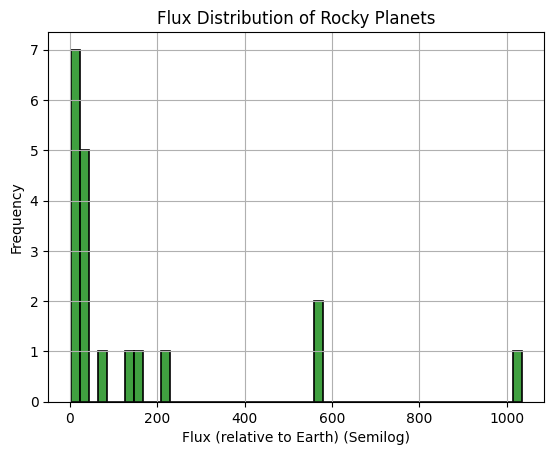

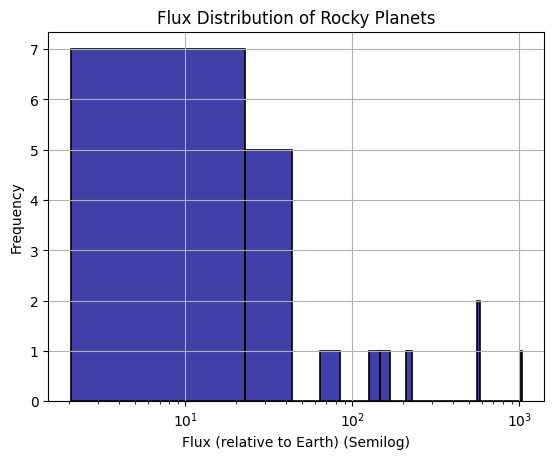

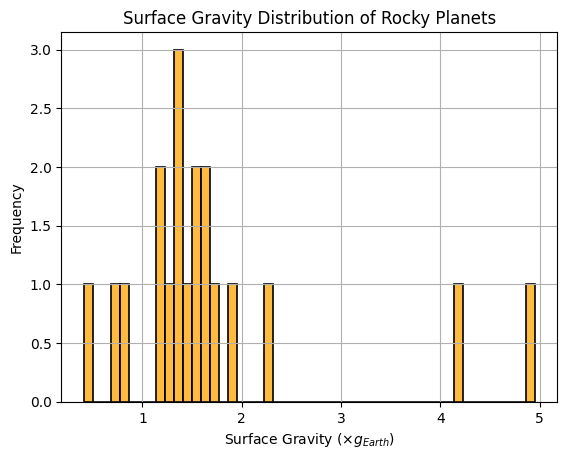

In [ ]:
#Flux Distribution

#Linear
sns.histplot(rocky_flux, bins=50, color='green', edgecolor='black', linewidth=1.2)

plt.xlabel("Flux (relative to Earth) (Semilog)")
plt.ylabel("Frequency")
plt.title("Flux Distribution of Rocky Planets")
plt.grid()
plt.show()

#Semilog
sns.histplot(rocky_flux, bins=50, color='darkblue', edgecolor='black', linewidth=1.2)

plt.xscale('log')
plt.xlabel("Flux (relative to Earth) (Semilog)")
plt.ylabel("Frequency")
plt.title("Flux Distribution of Rocky Planets")
plt.grid()
plt.show()


#Acceleration due to gravity plot

sns.histplot(g_vals, bins=50, color='orange', edgecolor='black', linewidth=1.2)

plt.xlabel(r"Surface Gravity ($\times g_{Earth}$)")
plt.ylabel("Frequency")
plt.title("Surface Gravity Distribution of Rocky Planets")
plt.grid()
plt.show()

#**10. Estimation of Temperature Using Bayesian MCMC Method**

Here, we used radiative equilibrium and greenhouse effect parameterization to estimate surface temperature $T_s$.

The formula used here is:

\begin{equation}
T_s =
\left( \frac{(1 - A)\,F}{4\sigma} \right)^{1/4} \left(1 + \frac{3}{4}\,\frac{\kappa P_s}{g} \right)^{1/4}
\end{equation}


where,

- $A$ is Albedo,

- $F$ is incident stellar flux

- $\sigma = 5.670374419×10^{-8}$ W/m^2 K^4 is Stefan's constant

- $\kappa$ is atmospheric opacity

- $P_s$ is surface pressure

- $g$ is acceleration due to gravity


It can be written as,

$$T_s = T_{eq} \times \text{greenhouse factor}$$

Here,

$$T_{eq} = \left( \frac{(1 - A)\,F}{4\sigma} \right)^{1/4}$$

is the equilibrium temperature in the absence of atmosphere and,

$$\left(1 + \frac{3}{4}\,\frac{\kappa P_s}{g} \right)^{1/4}$$

is the greenhouse factor.
This follows from integrating the radiative transfer equation under hydrostatic equilibrium.

###Optical Depth Parameterization

The optical depth is approximated as:

$$
\tau = \frac{\kappa P_s}{g}
$$

Gravity is expected to hold the atmosphere tighter, to prevent atmosphere run-off due to high energy stellar radiations like UV and X-rays.

Assumptions:

- Grey (wavelength-independent) atmosphere  

- Captures greenhouse effects via optical depth  

While simplified, it preserves the correct scaling relationships between
stellar flux, atmospheric properties, and surface temperature.


###Role in Bayesian Inference

We treated $A$, $\kappa$, and $P_s$ as latent parameters and inferred them using MCMC since data about them is not available and we need to revert back to theoretical estimations rather than measured data.

The likelihood is constructed by comparing the modeled temperature distribution
to a broad prior expectation for rocky planet surface temperatures:

$$
\mathcal{L} \propto \exp\left[-\frac{(T_s - \mu_T)^2}{2\sigma_T^2}\right]
$$

This allowed us to propagate uncertainty in atmospheric properties into
uncertainty in surface temperature estimates.


###Limitations

- Does not include convection or atmospheric dynamics  
- Assumes constant opacity (grey atmosphere)  
- $\kappa$ and $P_s$ are not independently identifiable (degeneracy)  
- Atmospheric composition is not explicitly modeled

In [ ]:
#Loading Data

df4 = pd.read_csv("Rocky_planets_flux_gravity.csv")

F = df4['flux'].to_numpy(dtype=float)
g = df4['g'].to_numpy(dtype=float)

sigma_sb = 5.670374419e-8


#Temperature Model

def T_surf(F, A, kappa, Ps, g):
    Teq = ((1 - A) * F / (4 * sigma_sb))**0.25
    tau = kappa * Ps / g
    return Teq * (1 + 0.75 * tau)**0.25


#Normalized Gaussian

def log_gaussian(x, mu, sigma):
    return -0.5 * ((x - mu) / sigma)**2 - np.log(sigma * np.sqrt(2 * np.pi))


#Likelihood

def log_likelihood(theta, F, g):
    A, log_kappa, log_Ps = theta

    if not (0 <= A <= 1):
        return -np.inf

    kappa = np.exp(log_kappa)
    Ps = np.exp(log_Ps)

    Ts = T_surf(F, A, kappa, Ps, g)

    mu_T, sig_T = 300, 200

    return np.sum(log_gaussian(Ts, mu_T, sig_T))


#Priors

def log_prior(theta):
    A, log_kappa, log_Ps = theta

    if not (0 <= A <= 1):
        return -np.inf

    return (
        log_gaussian(A, 0.3, 0.2) +
        log_gaussian(log_kappa, -2, 1.5) +   # opacity scale
        log_gaussian(log_Ps, 0, 2)           # pressure scale
    )


#Posterior

def log_post(theta, F, g):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, F, g)


#MCMC

ndim, nwalkers, steps = 3, 40, 3000

def run_sampler(init):
    pos = init + 1e-2 * np.random.randn(nwalkers, ndim)

    sampler = emcee.EnsembleSampler(
        nwalkers, ndim, log_post,
        args=(F, g)
    )

    sampler.run_mcmc(pos, steps, progress=True)
    return sampler.get_chain(discard=500, flat=True)


#Simulation

samples = run_sampler(np.array([0.3, -2, 0]))


#Temperature

A_s = samples[:,0]
kap_s = np.exp(samples[:,1])
Ps_s = np.exp(samples[:,2])

Ts_all = []

for i in range(len(F)):
    Ts_i = T_surf(F[i], A_s, kap_s, Ps_s, g[i])
    Ts_all.append(Ts_i)


#Summary

Ts_mean = [np.mean(t) for t in Ts_all]
Ts_std = [np.std(t) for t in Ts_all]

df4['Ts_mean'] = Ts_mean
df4['Ts_std'] = Ts_std


print(f"\nTotal Planets with Complete Information: {len(df4)}")


df4['Ts_mean'] = [np.mean(t) for t in Ts_all]
df4['Ts_std'] = [np.std(t) for t in Ts_all]

df4.to_csv("Rocky_planets_flux_gravity_temp.csv", index=False)
files.download("Rocky_planets_flux_gravity_temp.csv")

df4 = pd.read_csv("Rocky_planets_flux_gravity_temp.csv")

display(df4)

100%|██████████| 3000/3000 [00:08<00:00, 347.87it/s]



Total Planets with Complete Information: 19


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,pl_name,pl_masse,pl_rade,flux,g,Ts_mean,Ts_std
0,EPIC 249893012 b,8.750,1.950,1034.208839,2.301118,381.929089,87.932680
1,GJ 367 b,0.633,0.699,577.043182,1.295536,371.086719,95.199970
2,GJ 486 b,2.770,1.289,38.876181,1.667147,179.389846,44.046485
3,HD 224018 b,4.100,0.910,146.008621,4.951093,203.611082,38.490378
4,K2-136 b,4.300,1.014,34.065612,4.182082,145.650207,28.924848
5,K2-136 d,3.000,1.565,7.145645,1.224877,125.269130,32.428999
6,K2-32 e,2.100,1.212,213.592130,1.429598,283.522125,71.546194
7,L 98-59 b,0.320,0.884,24.106488,0.409492,216.683448,64.171015
8,L 98-59 c,2.220,1.358,12.488057,1.203797,144.564286,37.527073
9,L 98-59 d,1.870,1.576,4.890179,0.752886,126.661788,35.126477


#**11(a). Pearson and Spearman Correlation Heatmap**


Pearson Correlation:
           pl_masse   pl_rade      flux         g   Ts_mean
pl_masse  1.000000  0.707241  0.425945  0.449532  0.135540
pl_rade   0.707241  1.000000  0.114980 -0.198306 -0.101391
flux      0.425945  0.114980  1.000000  0.117576  0.886576
g         0.449532 -0.198306  0.117576  1.000000  0.026572
Ts_mean   0.135540 -0.101391  0.886576  0.026572  1.000000

Spearman Correlation:
           pl_masse   pl_rade      flux         g   Ts_mean
pl_masse  1.000000  0.638596  0.161404  0.743860  0.021053
pl_rade   0.638596  1.000000 -0.147368  0.114035 -0.168421
flux      0.161404 -0.147368  1.000000  0.445614  0.945614
g         0.743860  0.114035  0.445614  1.000000  0.243860
Ts_mean   0.021053 -0.168421  0.945614  0.243860  1.000000


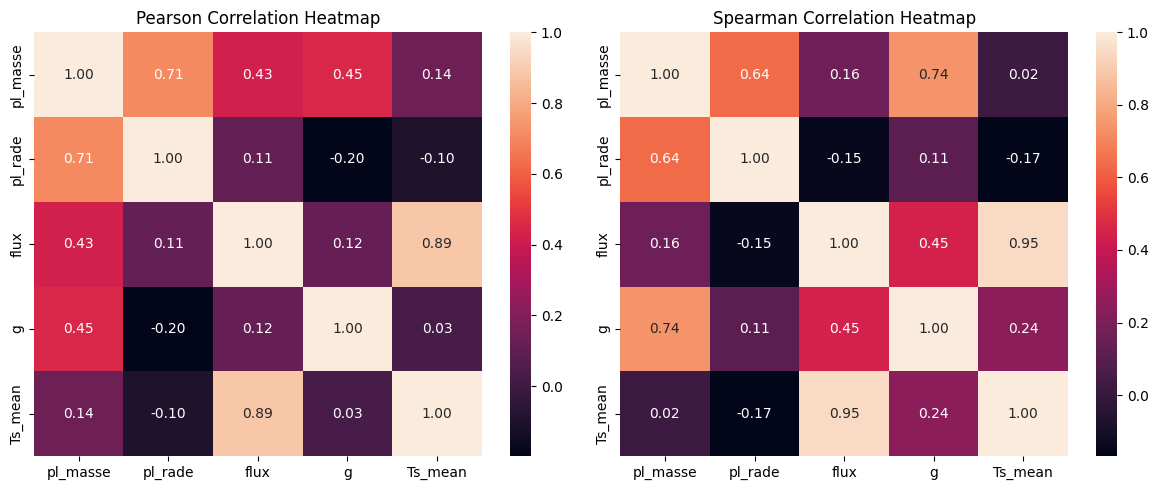

In [ ]:
cols = ['pl_masse', 'pl_rade', 'flux', 'g', 'Ts_mean']
df_corr = df4[cols].dropna()


#Correlations

corr_pearson = df_corr.corr(method='pearson')
corr_spearman = df_corr.corr(method='spearman')

print("\nPearson Correlation:\n", corr_pearson)
print("\nSpearman Correlation:\n", corr_spearman)


#Heatmaps

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(corr_pearson, annot=True, fmt=".2f")
plt.title("Pearson Correlation Heatmap")

plt.subplot(1,2,2)
sns.heatmap(corr_spearman, annot=True, fmt=".2f")
plt.title("Spearman Correlation Heatmap")

plt.tight_layout()
plt.show()

#**11(b). Correlation heatmap Using $\tau$**


Pearson Correlation:
               flux         g  tau_mean   Ts_mean
flux      1.000000  0.117576 -0.232717  0.886576
g         0.117576  1.000000 -0.674566  0.026572
tau_mean -0.232717 -0.674566  1.000000 -0.101148
Ts_mean   0.886576  0.026572 -0.101148  1.000000

Spearman Correlation:
               flux         g  tau_mean   Ts_mean
flux      1.000000  0.445614 -0.445614  0.945614
g         0.445614  1.000000 -1.000000  0.243860
tau_mean -0.445614 -1.000000  1.000000 -0.243860
Ts_mean   0.945614  0.243860 -0.243860  1.000000


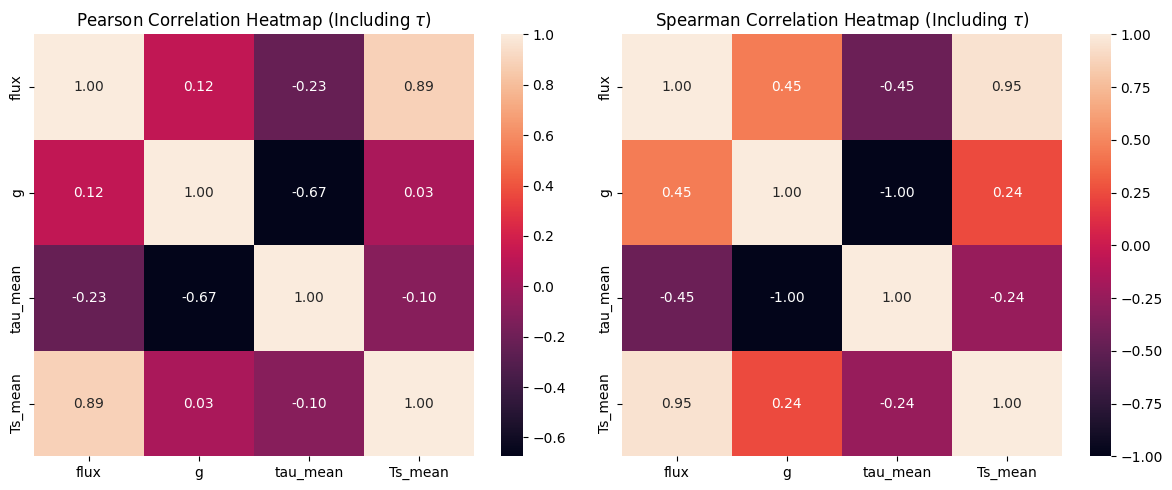

In [ ]:
#Tau calculation from MCMC samples     tau = k * Ps / g

A_s = samples[:, 0]
kappa_s = np.exp(samples[:, 1])
Ps_s = np.exp(samples[:, 2])

g = df4['g'].to_numpy(dtype=float)

tau_all = []

for i in range(len(g)):
    tau_i = kappa_s * Ps_s / g[i]
    tau_all.append(tau_i)

tau_mean = [np.mean(t) for t in tau_all]
df4['tau_mean'] = tau_mean


#Dependent Variables

cols = ['flux', 'g', 'tau_mean', 'Ts_mean']
df_corr = df4[cols].dropna()


#Correlations

corr_pearson = df_corr.corr(method='pearson')
corr_spearman = df_corr.corr(method='spearman')

print(f"\nPearson Correlation:\n {corr_pearson}")
print(f"\nSpearman Correlation:\n {corr_spearman}")


#Heatmaps

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(corr_pearson, annot=True, fmt=".2f")
plt.title(r"Pearson Correlation Heatmap (Including $\tau$)")

plt.subplot(1,2,2)
sns.heatmap(corr_spearman, annot=True, fmt=".2f")
plt.title(r"Spearman Correlation Heatmap (Including $\tau$)")

plt.tight_layout()
plt.show()

#**11(c). Inference**

##**Inference from Correlation Analysis**

###**1. Without τ (Using $M$, $R$, $g$)**

- Strong correlation:
  - $T_s$ vs flux is the dominant driver

- Weak correlations:
  - $T_s$ vs mass, radius, g shows negligible influence

- Strong internal correlations:
  - mass vs radius is high ($\approx$ 0.6–0.7)
  - mass vs g is moderate

###**Interpretation**
- Mass and radius do not directly influence temperature  
- Their effect is only through gravity:
  $$
  g \sim \frac{M}{R^2}
  $$
- Hence, they are **redundant variables**, not independent predictors



###**2. With $\tau$ (Replacing mass & radius)**

- Strong correlation:
  - $T_s$ vs flux remains dominant

- τ behavior:
  - Weak correlation with $T_s$
  - Strong anti-correlation with $g$ (≈ -1 in Spearman)

####**Interpretation**
- $\tau$ captures atmospheric effect:
  
  $$\tau = \frac{\kappa P_s}{g}$$

- Strong $\tau$–$g$ anti-correlation shows:
  
  $$\tau \propto \frac{1}{g}$$

- Indicates **degeneracy**:
  
  $$\kappa P_s \approx \text{constant}$$


###**3. Justification for Removing Mass and Radius**

- Mass and radius:
  - Do not appear in the temperature model directly
  - Only contribute via gravity

- Including them:
  - Introduces redundancy
  - Inflates correlation structure without adding information

- Replacing with $\tau$:
  - Aligns analysis with actual physics of the model
  - Captures the effective atmospheric parameter

####**Conclusion**
Mass and radius are **physically indirect and statistically redundant**,
and should be excluded in favor of variables (like τ) that directly
influence surface temperature.


###**4.Why τ Does Not Strongly Correlate with Temperature?**

Although theoretically:

$$T_s \propto (1 + 0.75\tau)^{1/4}$$

Observed weak correlation implies:
- Atmospheric parameters are not freely explored
- Degeneracy between $\kappa$ and $P_s$ limits τ variation
- Flux dominates temperature variation


### 5. Effective Model Behavior

The model reduces to:

$$
T_s \sim F^{1/4} \cdot \left(1 + \frac{C}{g} \right)^{1/4}
$$

where:
$$
C = \kappa P_s \approx \text{constant}
$$


###**4. Final Insight**

- Flux is the **primary driver of temperature**
- Gravity has a **secondary, indirect role**
- Atmospheric parameters collapse into a **single effective variable ($\tau$)**, but individual parameters need resolution
- The model is physically consistent but exhibits **parameter degeneracy**

#**12. Planets Which May Support Human Living Conditions**

In [ ]:
#Habitability Filter

habitable = df4[
    (df4['Ts_mean'] >= 263) & (df4['Ts_mean'] <= 333) &
    (df4['g'] >= 0.5) & (df4['g'] <= 2.0) &
    (df4['flux'] >= 0.5) & (df4['flux'] <= 5)
]

n = len(habitable)


if n == 0:
    print("No habitable exoplanet found to support life")
else:
    print(f"Potentially Habitable Planets: {n}\n")
    print(habitable[['pl_name', 'Ts_mean', 'g', 'flux']])

No habitable exoplanet found to support life


#**Result**

Current model did not find any exoplanet worthy of supporting human life even after considering controversial choices (or rather, outright crazy) tolerances of:

1. $263 K$ ($-10^{\circ} C$) $\, \leq \,$ $T$ $\,\leq \,$ $333 K$ ($+60^{\circ} C$).

2. $0.5$ $\, \leq \,$ $g$ $\, \leq \,$ $2.0$ (In Earth units).

3. $0.5$ $\, \leq \,$ Flux $\, \leq \,$ $5.0$ (In Earth Units).


###**Endnotes:**

It may be notes that our database of planets is really small and we assumed Earth-like life forms which are carbon and oxygen based only. There may be planets with Carbon Dioxide as the dominant life driver and organisms adapted to high or low flux, $g$ and $T$ compared to ours. Our main aim was to find exoplanets which may support Earth-like life, whose result is negative.

We need more complete data on existing planets with terrestrial and atmospheric compostion and new discoveries of planets. The best way to discover habitability is of course *in situ* explorations.

# 1. ANALYSIS OF ACCELRATION DUE TO GRAVITY
The first parameter we are analyzing is the surface gravity of the exoplanet. Surface gravity is a key parameter that affects atmospheric retention and surface conditions.

# Preprocsesing the data

The dataset was loaded and converted into numerical format and the invalid entries such as missing values and non-physical values were removed.
We also removed duplicate datas that may have arised due to frequent updation of the data set by retaining the entries with the lowest uncertainty.

$$
\text{Uncertainity Score} = \Delta R + \Delta M
$$

Where:
- $\Delta R$ = radius uncertainty  
- $\Delta M$ = mass uncertainty  

Here lower values indicate better data quality.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from scipy import stats
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')


file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name, comment='#')

# Converting to numeric values
numeric_cols = ['pl_rade', 'pl_masse', 'pl_radeerr1', 'pl_radeerr2', 'pl_masseerr1', 'pl_masseerr2']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Original rows: {len(df)}")

# Removing invalid data
df_valid = df.dropna(subset=['pl_name', 'pl_rade', 'pl_masse']).copy()
df_valid = df_valid[
    (df_valid['pl_rade'] > 0) &
    (df_valid['pl_masse'] > 0) &
    (df_valid['pl_name'].str.len() > 0)]
print(f"Valid data: {len(df_valid)} rows")

# Removing duplicate rows that may have arised due to updation, by taking the row having least combined error
df_valid['radius_err'] = np.abs(df_valid['pl_radeerr1'].fillna(0)) + np.abs(df_valid['pl_radeerr2'].fillna(0))
df_valid['mass_err'] = np.abs(df_valid['pl_masseerr1'].fillna(0)) + np.abs(df_valid['pl_masseerr2'].fillna(0))
df_valid['uncertainity_score'] = df_valid['radius_err'] + df_valid['mass_err']
df_unique = df_valid.sort_values('uncertainity_score').drop_duplicates('pl_name', keep='first')
print(f"Number of unique planets: {len(df_unique)}")


Original rows: 39554
Valid data: 3252 rows
Number of unique planets: 1651


# Calculation of surface gravity

We extracted the radius and mass of the exoplanet with their uncertainity from the NASA exoplanet archive and calculated the surface gravity using the Newton’s Law of Universal Gravitation

$$
g = \frac{GM}{R^2}
$$
Where:
- $G$ = gravitational constant = 6.674 x 10-11 m3 kg-1 s-2
- $M$ = mass of the planet  
- $R$ = radius of the planet
  
In Earth-normalized units:
$$
g = \frac{M}{R^2}
$$
This simplifies comparison with Earth's gravity.

# Error Propagation

Uncertainty in gravity is calculated using error propagation:


$$
\frac{\Delta g}{g} = \sqrt{\left(\frac{\Delta M}{M}\right)^2 + \left(2\frac{\Delta R}{R}\right)^2}
$$

The factor of 2 arises because radius is squared in the denominator.

This accounts for uncertainties in both mass and radius

To ensure reliability:

we remove the planets with very high uncertainty by applying the threshold:

$$
Relative error
<
500 \%
$$

This results in a cleaned dataset suitable for analysis.

# Classification of planets into Earth-like-gravity planets

Planets are classified as Earth-like if:
$$ 0.8
≤
𝑔
≤
1.5
$$
And if g is equal to 1, it is considered as the "best fit"

In [ ]:
# Calculating gravity g=M/r2 in earth units
df_unique['gravity_e'] = df_unique['pl_masse'] / (df_unique['pl_rade'] ** 2) #gravity_e is the Gravity in Earth units
df_unique['gravity_mssq'] = 9.81 * df_unique['gravity_e'] #Earths gravity = 9.81 approx

# Calculating relative error
df_unique['mass_rel_err'] = np.clip(np.abs(df_unique['pl_masseerr1'].fillna(0)) / df_unique['pl_masse'], 0, 10)
df_unique['radius_rel_err'] = np.clip(np.abs(df_unique['pl_radeerr1'].fillna(0)) / df_unique['pl_rade'], 0, 10)
df_unique['grav_rel_err'] = np.sqrt(df_unique['mass_rel_err']**2 + (2*df_unique['radius_rel_err'])**2)

# Final filtering
df_clean = df_unique[(df_unique['gravity_e'] > 0) & (df_unique['grav_rel_err'] < 5)].copy()
print(f"Number of planets after filtering : {len(df_clean)}")

# Identifying planets having gravity range in the habitable region ( earth like )
EARTH_g_LOW, EARTH_g_HIGH = 0.8, 1.5
LOW_ERR_MAX = 0.5
earth_like = df_clean[(df_clean['gravity_e'].between(EARTH_g_LOW, EARTH_g_HIGH)) &
                     (df_clean['grav_rel_err'] < LOW_ERR_MAX)]

print(f"\n{len(earth_like)} EARTH-LIKE GRAVITY PLANETS WERE FOUND - ({100*len(earth_like)/len(df_clean):.1f}%)")

# Gravity statistics
max_g = df_clean['gravity_e'].max()
min_g = df_clean['gravity_e'].min()
mean_g = df_clean['gravity_e'].mean()
median_g = df_clean['gravity_e'].median()
std_g = df_clean['gravity_e'].std()
grav_skew = skew(df_plot["gravity_e"].dropna())

# Best gravity match to Earth (closest to 1.0g)
if len(df_clean) > 0:
    best_g_idx = df_clean['gravity_e'].sub(1.0).abs().idxmin()
    best_g_match = f"{df_clean.loc[best_g_idx, 'pl_name']} (g={df_clean.loc[best_g_idx, 'gravity_e']:.2f})"
else:
    best_g_match = "None"

Number of planets after filtering : 1649

447 EARTH-LIKE GRAVITY PLANETS WERE FOUND - (27.1%)


# Visualizations

# Gravity Distribution Analysis

A histogram was used to study the distribution of surface gravity and Log scale was used due to wide range.
Additionally the skewness was also identified as it indicates the presence of  outliers.
$$ if Skewness > 0 ⇒ Right-skewed  distribution
$$
$$ if Skewness < 0 ⇒ Left-skewed  distribution
$$



# Quality vs Habitability Analysis

A scatter plot was used to analyze the relationship between gravity and measurement uncertainty where the
$$
X-axis: Relative error (\%)
$$
$$
Y-axis: Gravity
$$
$$
Color: Quality score
$$
Darker colour indicates high quality score or low uncertainity score, that is lower error and better reliability and Lighter colour indicates low quality score.

This helps identify reliable Earth-like planets.

# CORRELATION ANALYSIS

Correlation between between mass, radius, and surface gravity was computed using Pearson correlation where the Pearson correlation coefficient is given by:

$$
r = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}
$$

Where:
- $r$ = correlation coefficient  
- $\text{Cov}(X, Y)$ = covariance between variables $X$ and $Y$  
- $\sigma_X$ = standard deviation of $X$  
- $\sigma_Y$ = standard deviation of $Y$  

here if ,

- $r > 0$ : Positive correlation (both variables increase together)  
- $r < 0$ : Negative correlation (one increases while the other decreases)  
- $r = 0$ : No linear correlation  

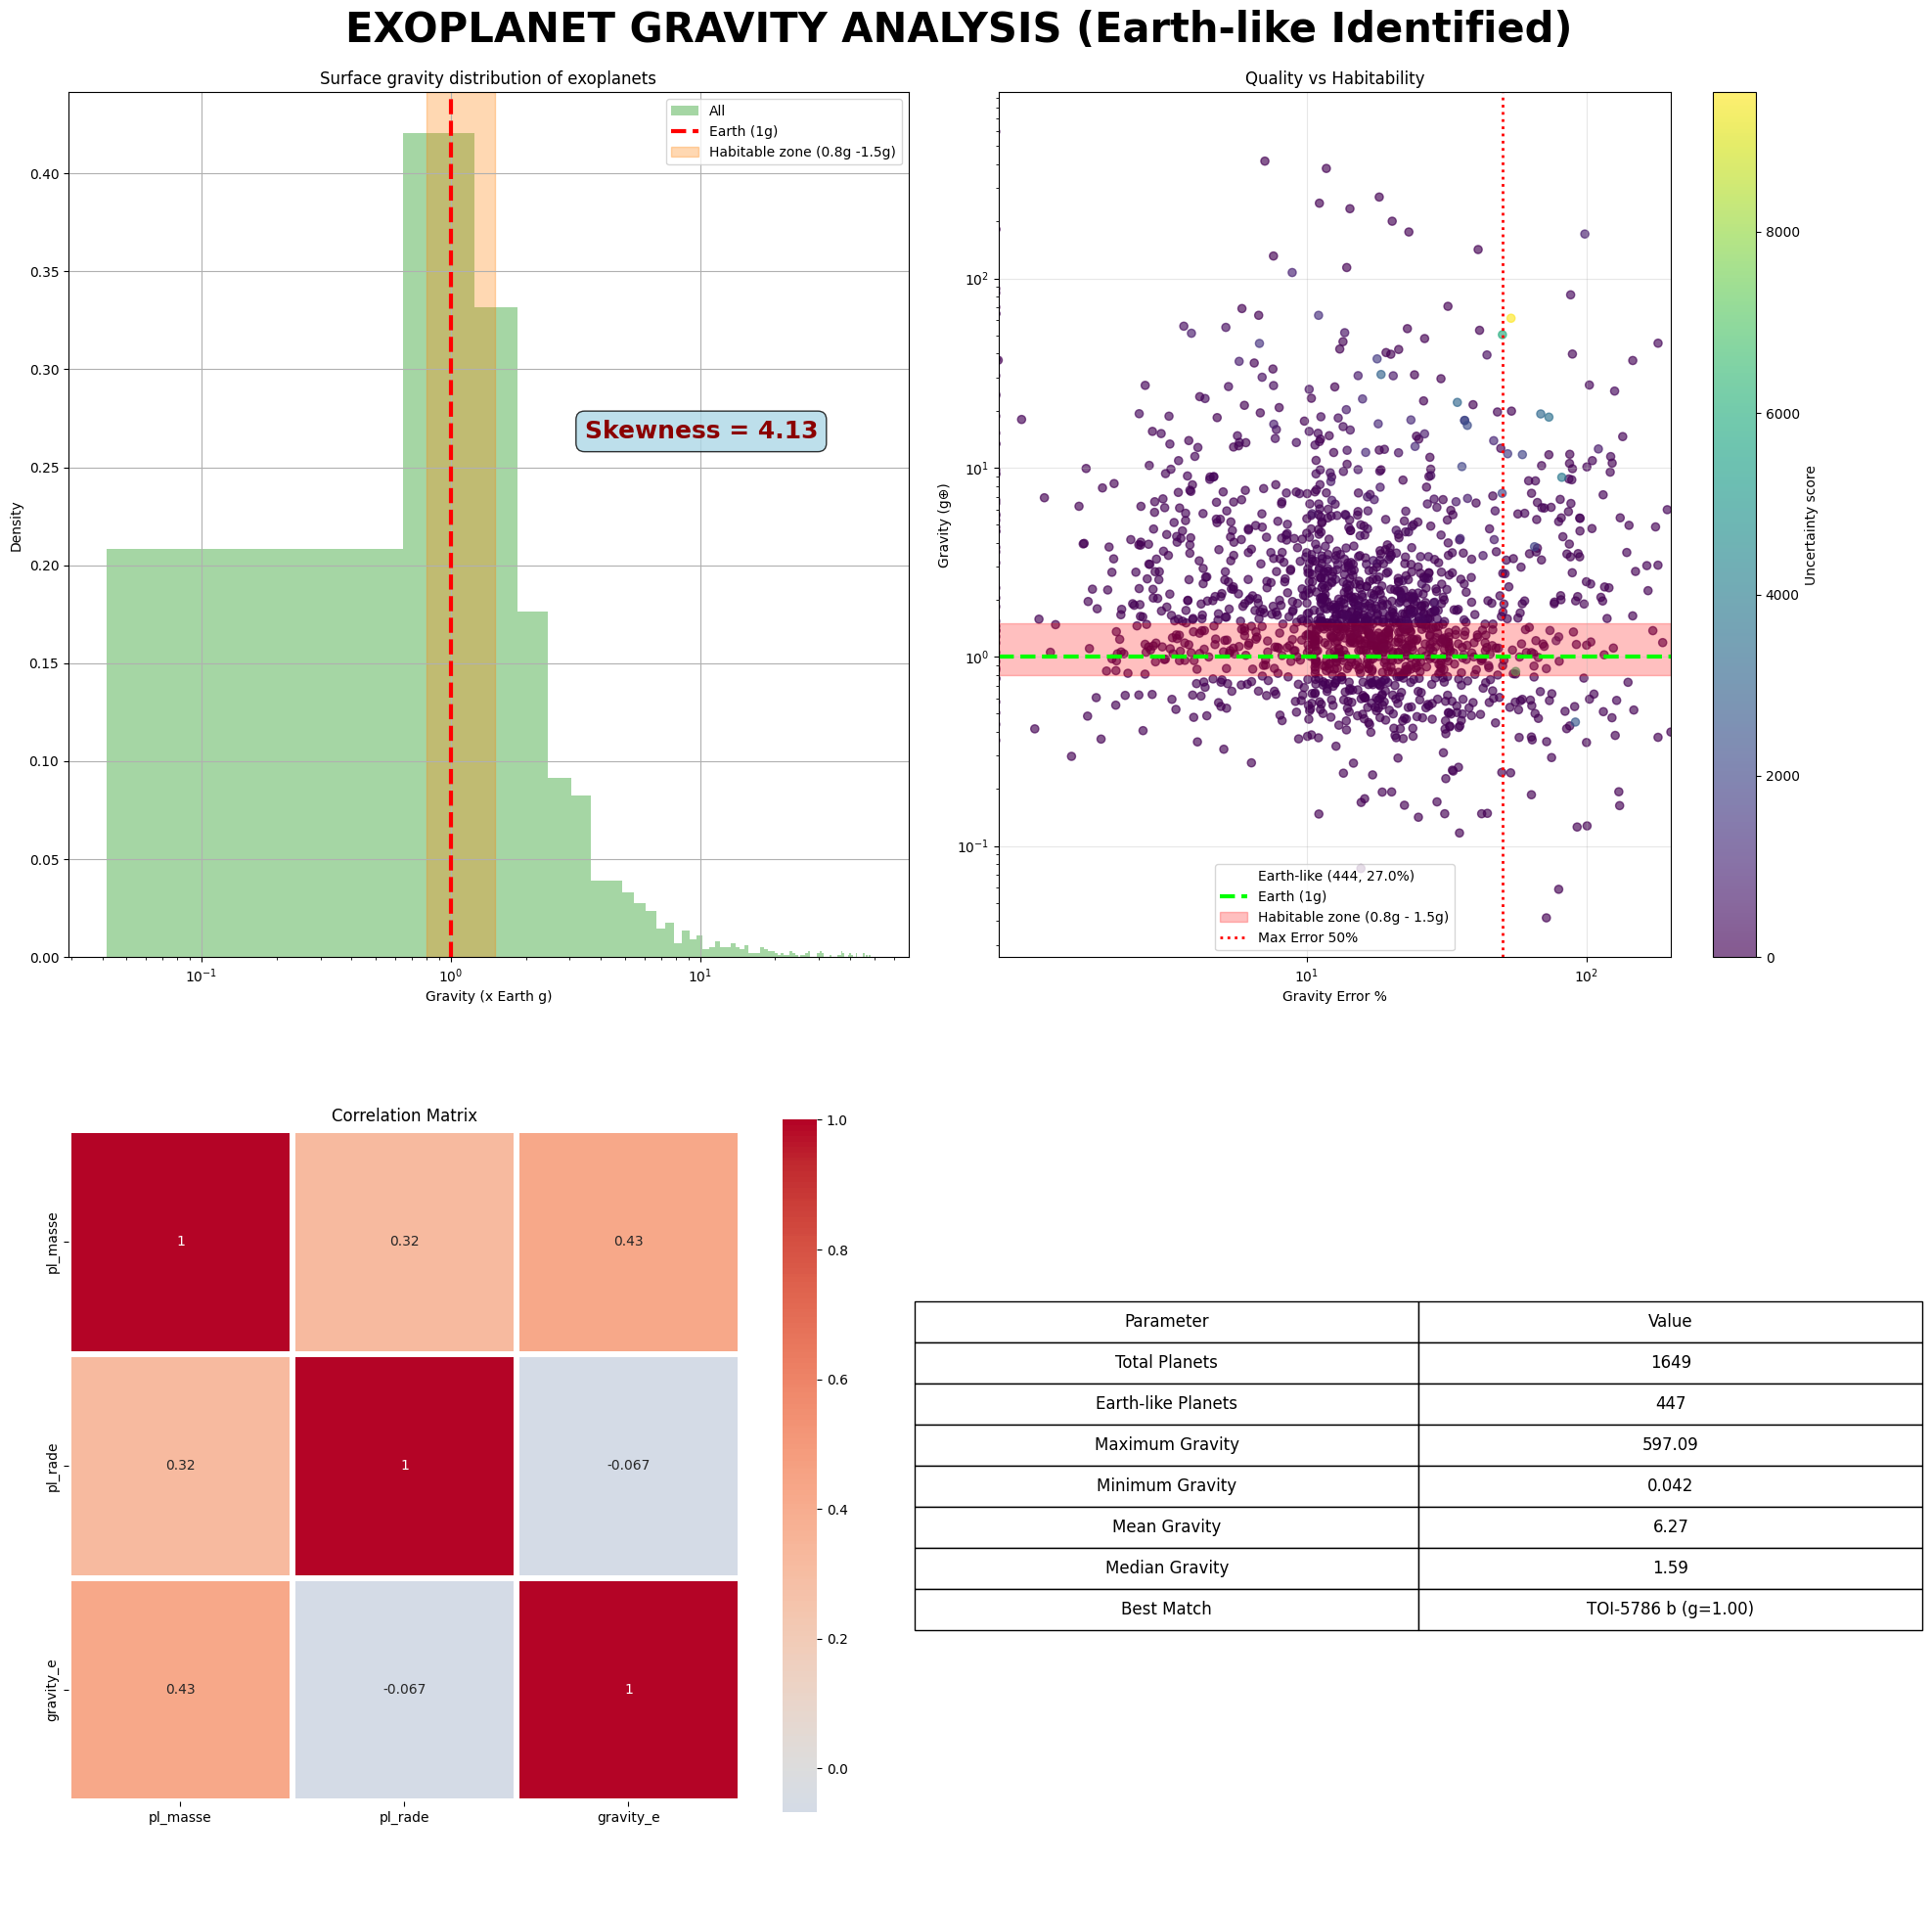

In [ ]:

#'''
# PLOTTING
fig, axes = plt.subplots(2,2, figsize=(20, 20))
fig.suptitle('EXOPLANET GRAVITY ANALYSIS (Earth-like Identified)', fontsize=30, weight='bold')


# 1. Gravity distribution
df_plot = df_clean[df_clean['gravity_e'] < 50]
earth_like_plot = earth_like[earth_like['gravity_e'] < 50]
axes[0,0].hist(df_plot['gravity_e'], bins=80, alpha=0.5,density=True, color='#4daf4a', label='All')
axes[0,0].axvline(1, color='r', lw=3, linestyle='--', label='Earth (1g) ')
axes[0,0].axvspan(EARTH_g_LOW, EARTH_g_HIGH, alpha=0.3,color='#ff7f00', label='Habitable zone (0.8g -1.5g)')
axes[0,0].set_xscale('log')
axes[0,0].set_xlabel('Gravity (x Earth g)')
axes[0,0].set_ylabel('Density')
axes[0,0].legend()
axes[0,0].set_title('Surface gravity distribution of exoplanets')
axes[0,0].grid(True)
# annotating skewness
tail_x = df_plot['gravity_e'].quantile(0.95)
ymax = axes[0,0].get_ylim()[1]
tail_y = ymax * 0.72

axes[0,0].annotate(f'Skewness = {grav_skew:.2f}',xy=(tail_x, tail_y),xytext=(tail_x/4, ymax*0.6),fontsize=18,fontweight='bold',color='darkred',bbox=dict(boxstyle='round,pad=0.35', facecolor='#ADD8E6', alpha=0.80))

# 2. Quality scatter
sc5 = axes[0,1].scatter(df_clean['grav_rel_err']*100, df_clean['gravity_e'], c=df_clean['uncertainity_score'], cmap='viridis', s=35, alpha=0.65)
axes[0,1].scatter(earth_like['grav_rel_err']*100, earth_like['gravity_e'], c='red', s=160, marker='', label='Earth-like (444, 27.0%)', zorder=10)
axes[0,1].axhline(1, color='lime', lw=3, linestyle='--', label='Earth (1g)')
axes[0,1].axhspan(0.8, 1.5, alpha=0.25, color='red', label='Habitable zone (0.8g - 1.5g)')
axes[0,1].axvline(LOW_ERR_MAX*100, color='red', ls=':', lw=2, label='Max Error 50%')
axes[0,1].set_xscale('symlog', linthresh=10)
axes[0,1].set_yscale('log')
axes[0,1].set_xlim(0.1, 200)
plt.colorbar(sc5, ax=axes[0,1], label='Uncertainty score')
axes[0,1].legend(loc='lower center')
axes[0,1].set_xlabel('Gravity Error %')
axes[0,1].set_ylabel('Gravity (g⊕)')
axes[0,1].set_title('Quality vs Habitability')
axes[0,1].grid(True, alpha=0.3)

# 3. Correlation matrix
corr_data = df_clean[['pl_masse', 'pl_rade', 'gravity_e']].corr()
sns.heatmap(corr_data, annot=True, cmap='coolwarm', center=0, ax=axes[1,0],
            square=True, linewidths=3, cbar_kws={'shrink':0.8})
axes[1,0].set_title('Correlation Matrix')
axes[1,1].axis('off')

# 4. Summary Table
axes[1,1].axis('off')

max_g = df_clean['gravity_e'].max()
min_g = df_clean['gravity_e'].min()
mean_g = df_clean['gravity_e'].mean()
median_g = df_clean['gravity_e'].median()

if len(df_clean) > 0:
    best_idx = df_clean['gravity_e'].sub(1.0).abs().idxmin()
    best_match = f"{df_clean.loc[best_idx, 'pl_name']} (g={df_clean.loc[best_idx, 'gravity_e']:.2f})"
else:
    best_match = "None"

table_data = [
    ['Total Planets', len(df_clean)],
    ['Earth-like Planets', len(earth_like)],
    ['Maximum Gravity', f'{max_g:.2f}'],
    ['Minimum Gravity', f'{min_g:.3f}'],
    ['Mean Gravity', f'{mean_g:.2f}'],
    ['Median Gravity', f'{median_g:.2f}'],
    ['Best Match', best_match]
]

table = axes[1,1].table(
    cellText=table_data,
    colLabels=['Parameter', 'Value'],
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.0)
plt.rcParams.update({'font.size': 20})
plt.tight_layout()
plt.show()
#'''


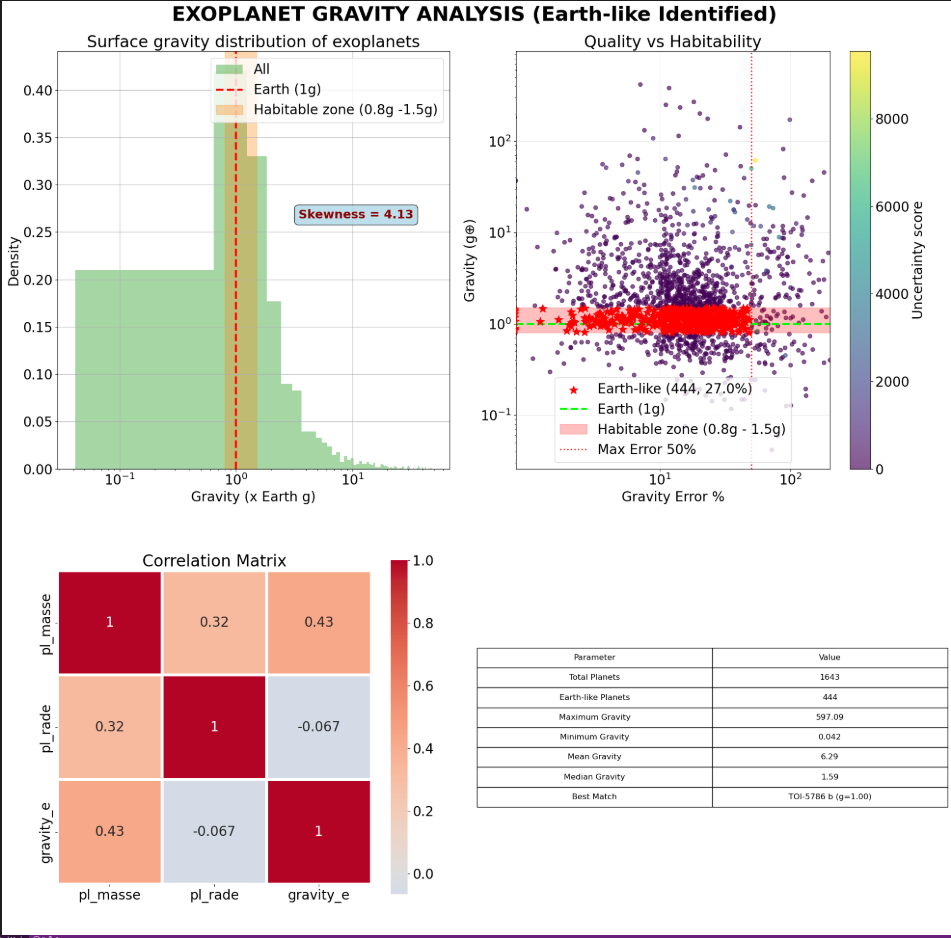